<a href="https://colab.research.google.com/github/nimisha442/ML_Projects/blob/main/HeartDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HEART DISEASE PREDICTION USING CLASSIFICATION MODELS

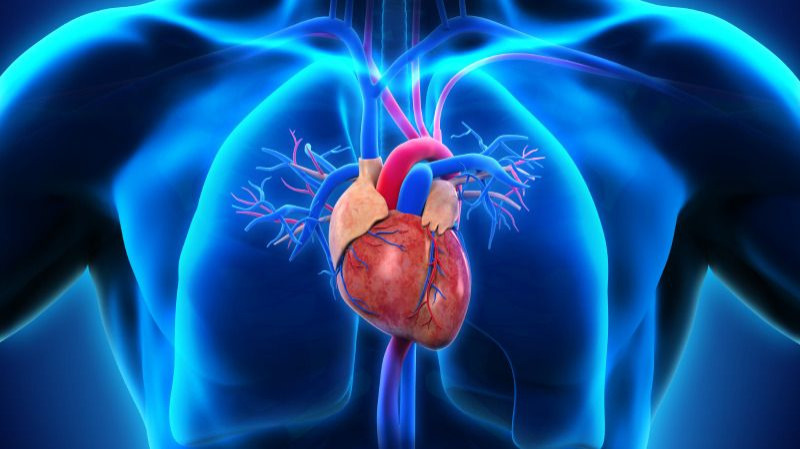

**INTRODUCTION :**

Heart disease remains one of the leading causes of mortality globally. Early diagnosis can significantly reduce risk and improve patient outcomes. This project leverages machine learning, specifically the  classification algorithms, to predict the presence of heart disease based on patient health data.By analyzing various clinical parameters, the study aimed to assist in the early detection and prevention of heart-related conditions through data-driven insights.








**OBJECTIVES :**

The primary objective of this project was to develop a predictive model capable of classifying whether a person was likely to have heart disease based on various clinical parameters. The study implemented and compared multiple machine learning algorithms — Random Forest, XGBoost, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM) — and evaluated their performance to identify the most accurate and reliable model.

**DATASET DISCRIPTION :**

The dataset used for this project contains anonymized health records of patients, with the following 14 features (columns):

age : Age of the patient

sex : Gender (1 = male; 0 = female)

cp : Chest pain type (0–3)

trestbps : Resting blood pressure (in mm Hg)

chol : Serum cholesterol in mg/dl

fbs : Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)

restecg : Resting electrocardiographic results (0–2)

thalach : Maximum heart rate achieved

exang : Exercise-induced angina (1 = yes; 0 = no)

oldpeak : ST depression induced by exercise relative to rest

slope : Slope of the peak exercise ST segment

ca : Number of major vessels (0–3) colored by fluoroscopy

thal : Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect)

target : Diagnosis of heart disease (1 = presence; 0 = absence)


**METHODOLOGY :**

The methodology adopted for this project followed a systematic approach to build a robust predictive model for heart disease detection. The steps were carried out as follows:

*Exploratory Data Analysis (EDA):*

* The dataset was examined to understand its structure, data types, and statistical properties.

* Missing values and inconsistencies were identified and analyzed.

* Relationships between features and the target variable were explored using statistical summaries.

*Data Visualization:*

* Various visualization techniques were used to identify patterns, trends, and anomalies in the data.

* Feature distributions were visualized to detect skewness or imbalance in the dataset.

* Correlations between variables were analyzed to understand their influence on heart disease prediction.

*Data Preprocessing:*

* Numerical features were normalized or scaled to ensure compatibility with machine learning algorithms.

* The dataset was divided into training and testing sets to enable effective model evaluation.

*Model Development:*

* Multiple machine learning algorithms, including Random Forest, XGBoost, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM), were implemented for classification.

*Model Evaluation:*

* Model performance was assessed using evaluation metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

* The results of different algorithms were compared to determine the most effective model for predicting heart disease.

*Cross-Validation:*

* K-fold cross-validation was applied to ensure that the model generalized well to unseen data and to minimize overfitting.

* The cross-validation results were used to validate the robustness and reliability of the model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


### EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
df.shape

(1025, 14)

In [ ]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


### DATA VISUALIZATION

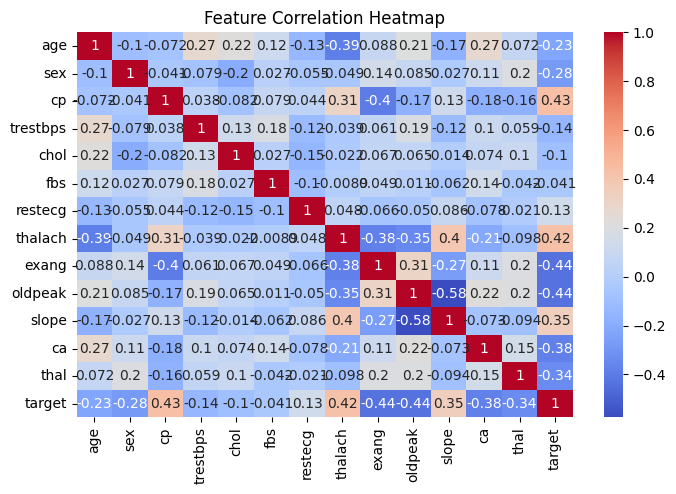

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

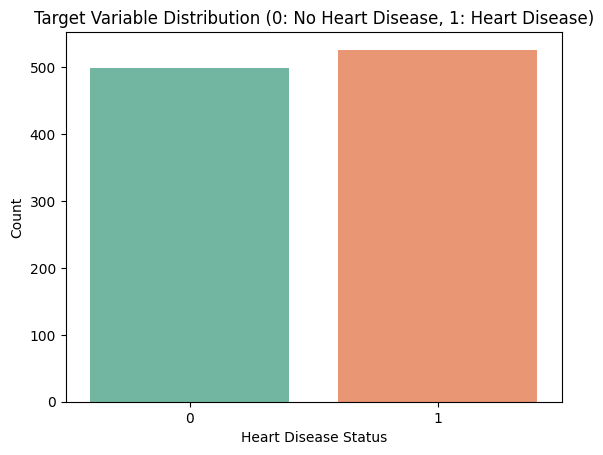

In [ ]:
#Target Variable Distribution
sns.countplot(x='target',data=df,palette='Set2')
plt.title('Target Variable Distribution (0: No Heart Disease, 1: Heart Disease)')
plt.xlabel('Heart Disease Status')
plt.ylabel('Count')
plt.show()

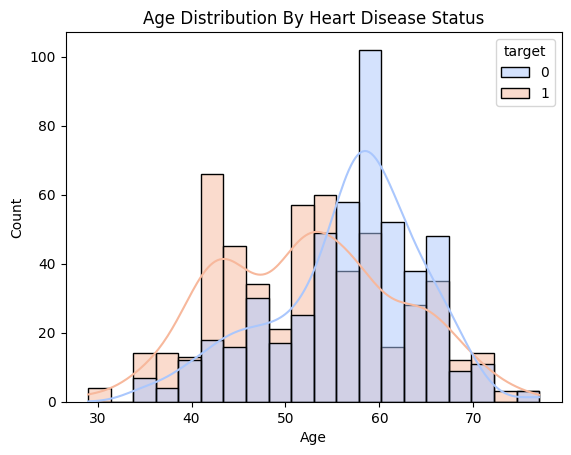

In [ ]:
#Age Distribution By Target
sns.histplot(x='age',hue='target',data=df,palette='coolwarm',kde=True,bins=20)
plt.title('Age Distribution By Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

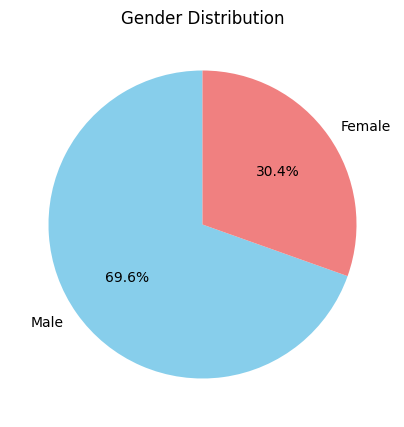

In [ ]:
plt.figure(figsize=(5,5))
df['sex'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,labels=['Male','Female'],colors=['skyblue','lightcoral'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

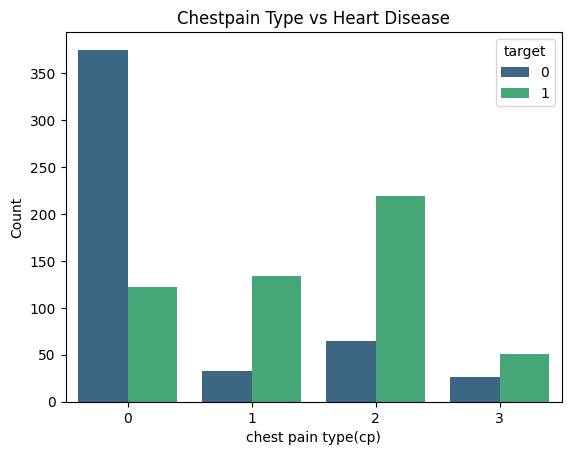

In [ ]:
#Chest pain vs Target

sns.countplot(data=df,x='cp',hue='target',palette='viridis')
plt.title('Chestpain Type vs Heart Disease')
plt.xlabel('chest pain type(cp)')
plt.ylabel('Count')
plt.show()

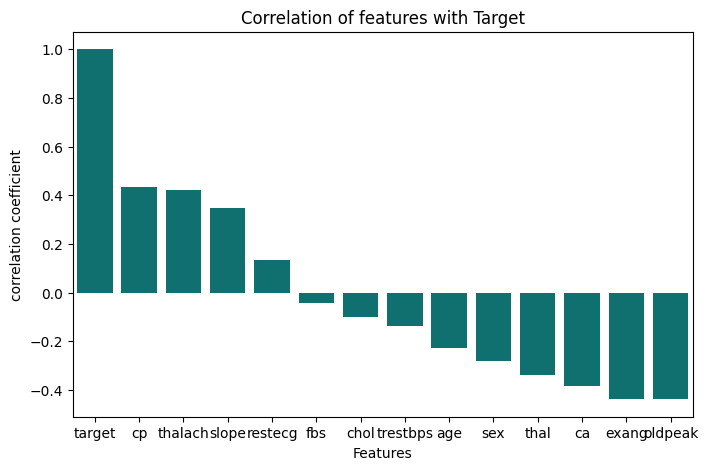

In [ ]:
#Correlation with target (sorted bar chart)
corr_target = df.corr()['target'].sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=corr_target.index,y=corr_target.values,color='teal')
plt.title('Correlation of features with Target')
plt.xlabel('Features')
plt.ylabel('correlation coefficient')
plt.show()

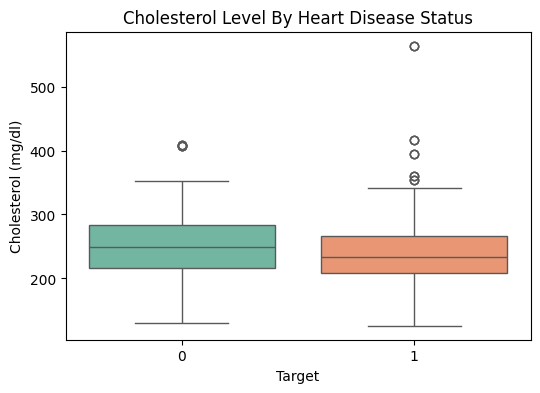

In [ ]:
#Boxplot cholesterol vs target

plt.figure(figsize=(6,4))
sns.boxplot(x='target',y='chol',data=df,palette='Set2')
plt.title('Cholesterol Level By Heart Disease Status')
plt.xlabel('Target')
plt.ylabel('Cholesterol (mg/dl)')
plt.show()

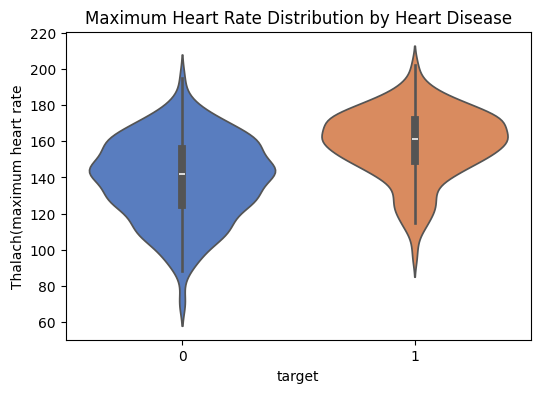

In [ ]:
#Violin Plot maximum heart rate(thalach)

plt.figure(figsize=(6,4))

sns.violinplot(x='target',y='thalach',data=df,palette='muted')
plt.title('Maximum Heart Rate Distribution by Heart Disease')
plt.xlabel('target')
plt.ylabel('Thalach(maximum heart rate')
plt.show()

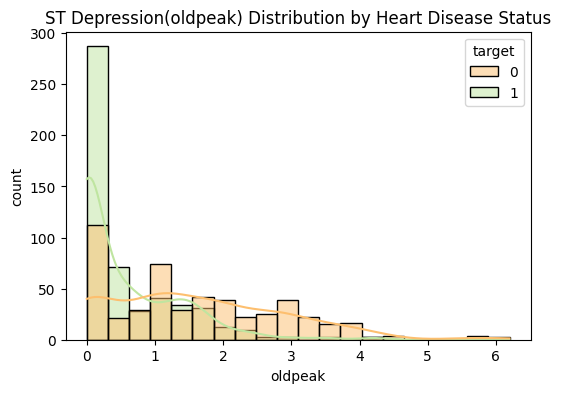

In [ ]:
#Histogram oldpeak(ST depression)

plt.figure(figsize=(6,4))
sns.histplot(data=df,x='oldpeak',hue='target',bins=20,kde=True,palette='Spectral')
plt.title('ST Depression(oldpeak) Distribution by Heart Disease Status')
plt.xlabel('oldpeak')
plt.ylabel('count')
plt.show()

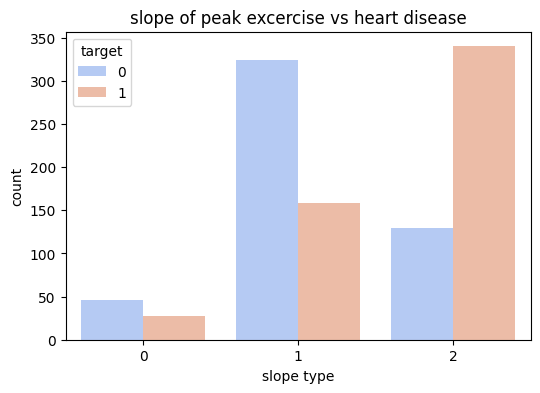

In [ ]:
#countplot slope vs target

plt.figure(figsize=(6,4))
sns.countplot(x='slope',hue='target',data=df,palette='coolwarm')
plt.title('Slope of Peak Excercise vs Heart Disease')
plt.xlabel('slope type')
plt.ylabel('count')
plt.show()

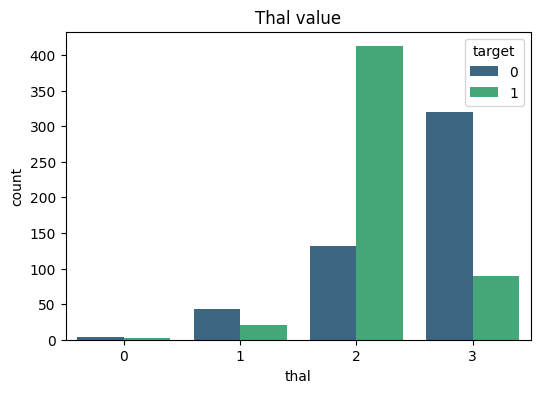

In [ ]:
#Thal vs target

plt.figure(figsize=(6,4))
sns.countplot(x='thal',hue='target',data=df,palette='viridis')
plt.title('Thal value')
plt.xlabel('thal')
plt.ylabel('count')
plt.show()

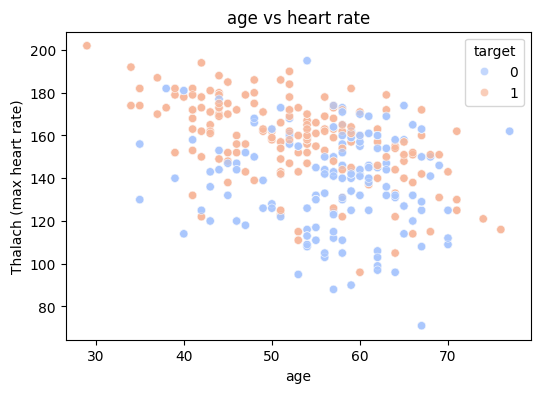

In [ ]:
#scatter plot age vs heart rate

plt.figure(figsize=(6,4))
sns.scatterplot(x='age',y='thalach',data=df,hue='target',palette='coolwarm',alpha=0.7)
plt.title('Age vs Heart Rate')
plt.xlabel('age')
plt.ylabel('Thalach (max heart rate)')
plt.show()

Text(0.5, 1.02, 'Pairwise Relationships Between Features')

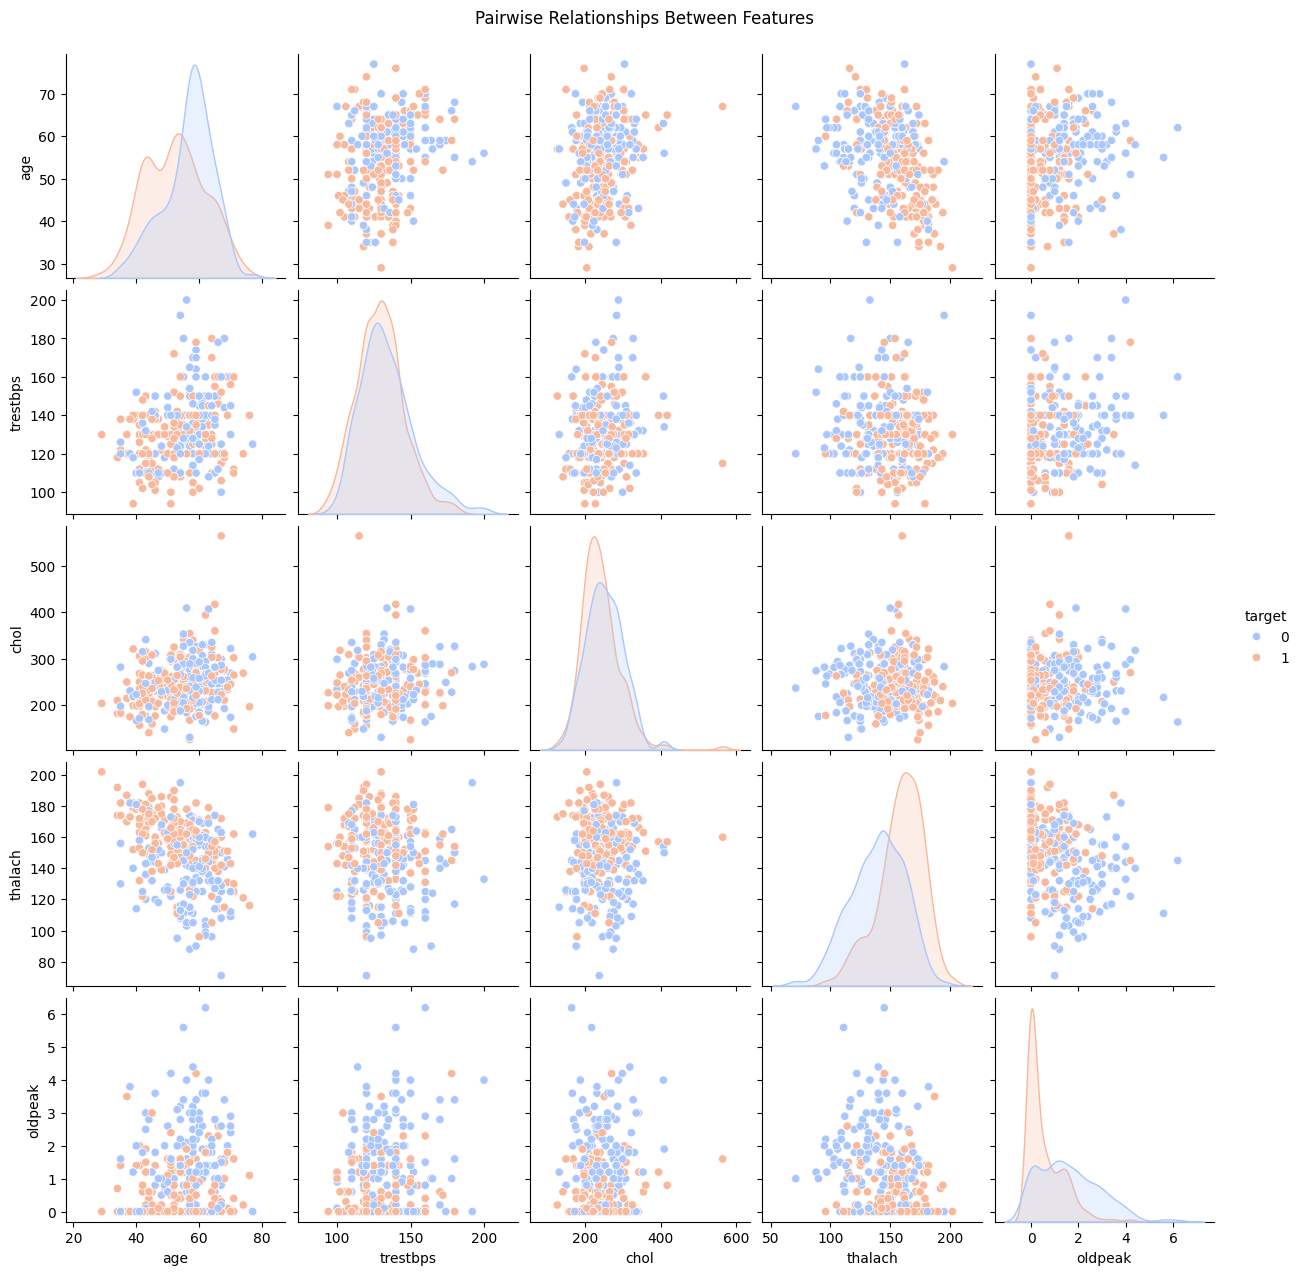

In [ ]:
#pairplot (feature relationships)
sns.pairplot(df[['age','trestbps','chol','thalach','oldpeak','target']],hue='target',diag_kind='kde',palette='coolwarm')
plt.suptitle('Pairwise Relationships Between Features',y=1.02 )

### DATA PREPROCESSING

In [ ]:
#seperate x and y

x =  df.iloc[:,:-1].values
x

array([[52.,  1.,  0., ...,  2.,  2.,  3.],
       [53.,  1.,  0., ...,  0.,  0.,  3.],
       [70.,  1.,  0., ...,  0.,  0.,  3.],
       ...,
       [47.,  1.,  0., ...,  1.,  1.,  2.],
       [50.,  0.,  0., ...,  2.,  0.,  2.],
       [54.,  1.,  0., ...,  1.,  1.,  3.]])

In [ ]:
y = df.iloc[:,-1].values
y

array([0, 0, 0, ..., 0, 1, 0])

In [ ]:
#model selection
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)
x_train

array([[59.,  1.,  1., ...,  2.,  0.,  2.],
       [58.,  1.,  0., ...,  1.,  3.,  3.],
       [44.,  0.,  2., ...,  1.,  1.,  2.],
       ...,
       [51.,  1.,  0., ...,  2.,  0.,  3.],
       [43.,  1.,  0., ...,  2.,  0.,  3.],
       [52.,  1.,  0., ...,  2.,  1.,  2.]])

In [ ]:
x_test

array([[62.,  0.,  0., ...,  2.,  0.,  2.],
       [53.,  0.,  2., ...,  2.,  0.,  0.],
       [55.,  1.,  0., ...,  1.,  1.,  3.],
       ...,
       [70.,  1.,  2., ...,  1.,  1.,  3.],
       [67.,  1.,  0., ...,  1.,  2.,  2.],
       [64.,  1.,  2., ...,  2.,  0.,  2.]])

In [ ]:
y_train

array([1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,

In [ ]:
y_test

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,

FEATURE SCALING

In [ ]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit_transform(x_train,x_test)
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

### MODEL CREATION AND PERFORMANCE EVALUATION

In [ ]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(x_train,y_train)

y_predRF = model_rf.predict(x_test)
y_predRF

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print(model_rf)
print(confusion_matrix(y_test,y_predRF))
print('**** ********** **** ********** ****')
print('accuracy_score:',accuracy_score(y_test,y_predRF))
print('**** ********** **** ********** ****')
print(classification_report(y_test,y_predRF))


RandomForestClassifier()
[[159   0]
 [  3 146]]
**** ********** **** ********** ****
accuracy_score: 0.9902597402597403
**** ********** **** ********** ****
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       159
           1       1.00      0.98      0.99       149

    accuracy                           0.99       308
   macro avg       0.99      0.99      0.99       308
weighted avg       0.99      0.99      0.99       308



In [ ]:
#XGBoost Model

from xgboost import XGBClassifier
model_xgb = XGBClassifier(use_label_encoder=False, eval_matrics='logloss')
model_xgb.fit(x_train,y_train)

y_predXGB = model_xgb.predict(x_test)
y_predXGB

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,

In [ ]:
#from sklearn.metircs import confusion_matrix,accuracy_score,classification_report
print(confusion_matrix(y_test,y_predXGB))
print('**** ********** **** ********** ****')
print('accuracy_score:',accuracy_score(y_test,y_predXGB))
print('**** ********** **** ********** ****')
print(classification_report(y_test,y_predXGB))

[[113  46]
 [ 12 137]]
**** ********** **** ********** ****
accuracy_score: 0.8116883116883117
**** ********** **** ********** ****
              precision    recall  f1-score   support

           0       0.90      0.71      0.80       159
           1       0.75      0.92      0.83       149

    accuracy                           0.81       308
   macro avg       0.83      0.82      0.81       308
weighted avg       0.83      0.81      0.81       308



In [ ]:
#KNN Model

from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train,y_train)

y_predKNN = model_knn.predict(x_test)
y_predKNN


array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,

In [ ]:
print(confusion_matrix(y_test,y_predKNN))
print('**** ********** **** ********** ****')
print('accuracy_score:',accuracy_score(y_test,y_predKNN))
print('**** ********** **** ********** ****')
print(classification_report(y_test,y_predKNN))
print('**** ********** **** ********** ****')

[[131  28]
 [ 14 135]]
**** ********** **** ********** ****
accuracy_score: 0.8636363636363636
**** ********** **** ********** ****
              precision    recall  f1-score   support

           0       0.90      0.82      0.86       159
           1       0.83      0.91      0.87       149

    accuracy                           0.86       308
   macro avg       0.87      0.86      0.86       308
weighted avg       0.87      0.86      0.86       308

**** ********** **** ********** ****


In [ ]:
#SVM  Model
from sklearn.svm import SVC
model_svm = SVC()
model_svm.fit(x_train,y_train)

y_predSVM = model_svm.predict(x_test)
y_predSVM


array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,

In [ ]:
print(confusion_matrix(y_test,y_predSVM))
print('**** ********** **** ********** ****')
print('accuracy_score:',accuracy_score(y_test,y_predSVM))
print('**** ********** **** ********** ****')
print(classification_report(y_test,y_predSVM))
print('**** ********** **** ********** ****')

[[135  24]
 [  6 143]]
**** ********** **** ********** ****
accuracy_score: 0.9025974025974026
**** ********** **** ********** ****
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       159
           1       0.86      0.96      0.91       149

    accuracy                           0.90       308
   macro avg       0.91      0.90      0.90       308
weighted avg       0.91      0.90      0.90       308

**** ********** **** ********** ****


 MODEL COMPARISON

In [ ]:
for i in [model_rf,model_knn,model_svm,model_xgb]:
  i.fit(x_train,y_train)
  print(i)
  y_pred = i.predict(x_test)
  print('accuracy_score',accuracy_score(y_test,y_pred))


RandomForestClassifier()
accuracy_score 0.9902597402597403
KNeighborsClassifier()
accuracy_score 0.8636363636363636
SVC()
accuracy_score 0.9025974025974026
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_matrics='logloss',
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)
accuracy_score 0.8116883116883117


### CROSS - VALIDATION + VISUALIZATION OF MODEL PERFORMANCE

In [ ]:
from sklearn.model_selection import cross_val_score

models = [model_rf,model_xgb,model_knn,model_svm]
model_names = ['Random_Forest','XGBoost','KNN','SVM']

for name, model in zip(model_names,models):
  print(f"\n=== {name} ===")
  acc_scores = cross_val_score(model,x,y,cv=5,scoring='accuracy')
  roc_scores = cross_val_score(model,x,y,cv=5,scoring='roc_auc')
  print('Mean Accuracy:',acc_scores.mean(),'Std Accuracy:',acc_scores.std())
  print('Mean ROC AUC:',roc_scores.mean(),'Std ROC AUC:',roc_scores.std())




=== Random_Forest ===
Mean Accuracy: 0.9970731707317073 Std Accuracy: 0.005853658536585371
Mean ROC AUC: 0.9998856489422527 Std ROC AUC: 0.0002287021154945279

=== XGBoost ===
Mean Accuracy: 0.9931707317073171 Std Accuracy: 0.008505168670323273
Mean ROC AUC: 1.0 Std ROC AUC: 4.965068306494546e-17

=== KNN ===
Mean Accuracy: 0.7473170731707317 Std Accuracy: 0.018867394737379254
Mean ROC AUC: 0.8674515668817555 Std ROC AUC: 0.013547371614639373

=== SVM ===
Mean Accuracy: 0.7034146341463415 Std Accuracy: 0.029333261226093466
Mean ROC AUC: 0.7555492825832448 Std ROC AUC: 0.03558998926400718


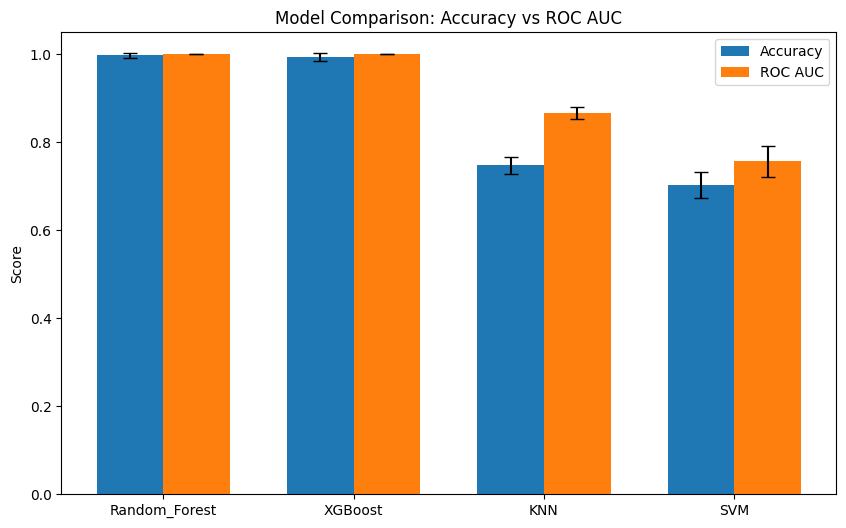

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ['Random_Forest','XGBoost','KNN','SVM']
accuracy_means = [0.997, 0.993, 0.747, 0.703]
accuracy_std = [0.0059, 0.0085, 0.0189, 0.0293]
roc_means = [0.9999, 1.0, 0.867, 0.756]
roc_std = [0.00023, 0.0, 0.0135, 0.0356]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, accuracy_means, width, yerr=accuracy_std, label='Accuracy', capsize=5)
ax.bar(x + width/2, roc_means, width, yerr=roc_std, label='ROC AUC', capsize=5)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0,1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Accuracy vs ROC AUC")
ax.legend()

plt.show()


**RESULT :**

After implementing and evaluating the selected machine learning algorithms, the models demonstrated varying levels of accuracy and generalization capability. The Random Forest Classifier achieved the highest performance among all the models tested.

Model Accuracy Scores:

* Random Forest Classifier: 0.9903

* K-Nearest Neighbors (KNN): 0.8636

* Support Vector Machine (SVM): 0.9026

* XGBoost Classifier: 0.8117

The Random Forest model exhibited superior predictive accuracy, indicating its robustness in handling non-linear relationships and feature interactions within the dataset.

Based on both single-run and cross-validation performance, the Random Forest Classifier emerged as the most effective model for predicting heart disease, achieving nearly perfect accuracy and AUC scores. XGBoost also performed competitively, though slightly below Random Forest in consistency.

**CONCLUSION**

This project successfully demonstrated the use of machine learning algorithms for predicting heart disease based on clinical parameters. Through systematic data preprocessing, visualization, and model evaluation, the Random Forest Classifier proved to be the most reliable model, achieving the highest accuracy and ROC-AUC scores.

The study highlighted that ensemble learning methods, particularly Random Forest, can effectively capture complex patterns in medical data and deliver superior predictive performance compared to individual algorithms like KNN, SVM, and XGBoost.

The findings reinforced the potential of machine learning as a valuable tool for supporting early diagnosis and aiding healthcare professionals in identifying individuals at risk of heart disease.


**FUTURE SCOPE** :

The project could be further extended and enhanced in several ways:

* Larger and More Diverse Datasets:
Future work could incorporate larger and more diverse datasets from multiple hospitals or regions to improve the generalizability and robustness of the model.

* Feature Engineering and Selection:
Advanced feature selection and engineering techniques could be employed to identify the most influential clinical parameters contributing to heart disease risk.

* Integration with Deep Learning:
Neural network–based models, such as Deep Neural Networks (DNN) or Convolutional Neural Networks (CNN) for tabular data, could be explored to improve prediction performance.

* Deployment in Real-Time Applications:
The predictive model could be integrated into healthcare management systems or mobile health applications to assist doctors in early diagnosis and patient monitoring.

* Explainable AI (XAI):
Incorporating explainability techniques such as SHAP or LIME would provide interpretability, helping medical practitioners understand how each feature influences predictions.

* Inclusion of Lifestyle and Genetic Factors:
Future models could integrate lifestyle habits, genetic information, and other health indicators to enhance the comprehensiveness of prediction.
